# Домашнее задание: Предсказание Customer Livetime Value (CLV) на датасете  https://www.kaggle.com/pankajjsh06/ibm-watson-marketing-customer-value-data






## Часть 1. EDA

Цель текущего анализа:
- подготовить данные к задаче **регрессии**, с целевой переменной = `Customer Lifetime Value`;
- проверить качество данных;
- изучить распределения признаков и связи с целевой переменной.

### 1. Импорт библиотек и настройки

- единый стиль графиков делает сравнение результатов проще;
- подключаем минимальный набор библиотек, нужный именно для EDA.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


### 2. Загрузка данных

- фиксируем источник данных;
- проверяем размер датасета;
- сразу убеждаемся, что целевая переменная присутствует.


In [3]:
DATA_PATH = 'WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv'
TARGET = 'Customer Lifetime Value'

df = pd.read_csv(DATA_PATH)

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(f'Целевая переменная: {TARGET}')
print('Target найден в данных:', TARGET in df.columns)
df.head()


Размер датасета: 9134 строк, 24 столбцов
Целевая переменная: Customer Lifetime Value
Target найден в данных: True


,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


### 3. Первичный обзор структуры

- обзор типов признаков;
- видим, какие поля категориальные/числовые;
- заранее отмечаем признаки, требующие преобразований (например, дата).


In [4]:
print('Список признаков:')
for col in df.columns:
    print('-', col)


Список признаков:
- Customer
- State
- Customer Lifetime Value
- Response
- Coverage
- Education
- Effective To Date
- EmploymentStatus
- Gender
- Income
- Location Code
- Marital Status
- Monthly Premium Auto
- Months Since Last Claim
- Months Since Policy Inception
- Number of Open Complaints
- Number of Policies
- Policy Type
- Policy
- Renew Offer Type
- Sales Channel
- Total Claim Amount
- Vehicle Class
- Vehicle Size


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

### 4. Проверка качества данных

- пропуски, дубликаты и некорректные форматы могут искажать EDA и будущую модель;
- на этом шаге выполняем диагностику, без препроцессинга.


In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_ratio_%': missing_ratio})

print('Признаки с пропусками:')
display(missing_table[missing_table['missing_count'] > 0])


Признаки с пропусками:


,missing_count,missing_ratio_%


In [7]:
duplicates_count = df.duplicated().sum()
print(f'Количество полных дубликатов строк: {duplicates_count}')


Количество полных дубликатов строк: 0


### 5. Разделение признаков на числовые и категориальные

- для каждой группы признаков требуется применять разные методы анализа;
- удобно формировать списки признаков для следующих этапов.


In [8]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

feature_num_cols = [c for c in num_cols if c != TARGET]

print(f'Числовых признаков (включая target): {len(num_cols)}')
print(num_cols)
print('-' * 80)
print(f'Числовых признаков (без target): {len(feature_num_cols)}')
print(feature_num_cols)
print('-' * 80)
print(f'Категориальных признаков: {len(cat_cols)}')
print(cat_cols)


Числовых признаков (включая target): 8
['Customer Lifetime Value', 'Income', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Total Claim Amount']
--------------------------------------------------------------------------------
Числовых признаков (без target): 7
['Income', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Total Claim Amount']
--------------------------------------------------------------------------------
Категориальных признаков: 16
['Customer', 'State', 'Response', 'Coverage', 'Education', 'Effective To Date', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size']


### 6. Анализ целевой переменной `Customer Lifetime Value`

- target в регрессии нужно изучить отдельно;
- проверяем форму распределения, асимметрию и выбросы;
- это влияет на выбор метрики и возможные преобразования (например, логарифмирование).


In [9]:
clv_stats = df[TARGET].describe()
print('Описательная статистика по target:')
print(clv_stats)


Описательная статистика по target:
count     9134.000000
mean      8004.940475
std       6870.967608
min       1898.007675
25%       3994.251794
50%       5780.182197
75%       8962.167041
max      83325.381190
Name: Customer Lifetime Value, dtype: float64


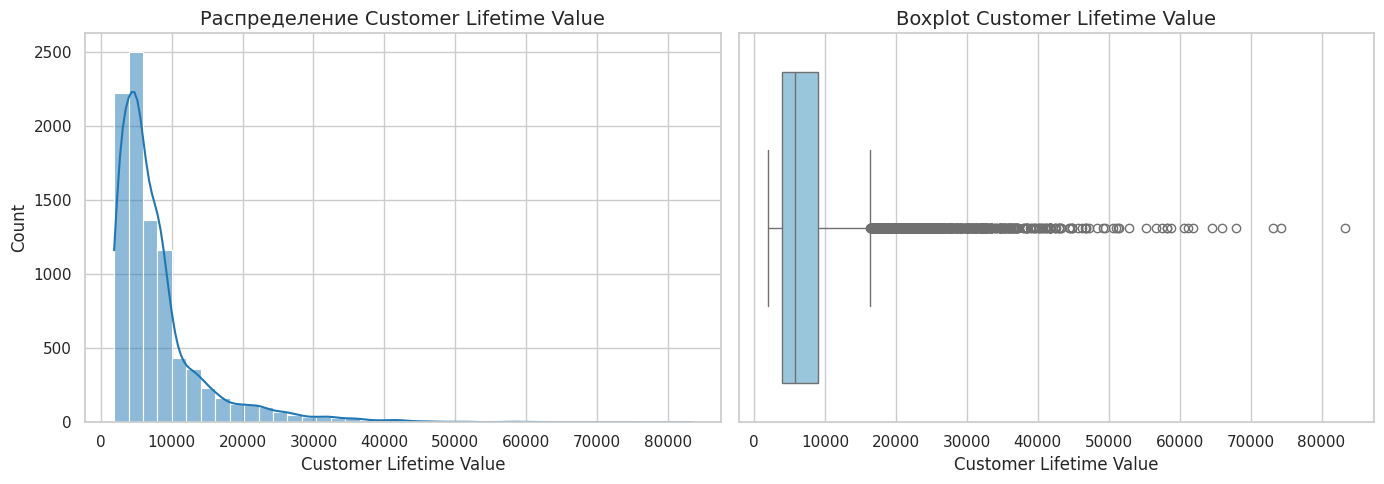

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[TARGET], kde=True, bins=40, ax=axes[0], color='#1f77b4')
axes[0].set_title('Распределение Customer Lifetime Value')

sns.boxplot(x=df[TARGET], ax=axes[1], color='#8ecae6')
axes[1].set_title('Boxplot Customer Lifetime Value')

plt.tight_layout()
plt.show()


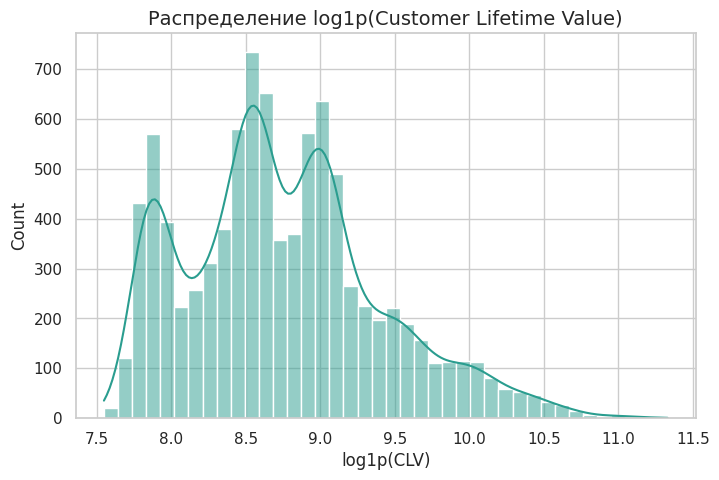

In [11]:
# Лог-вид target помогает лучше увидеть структуру при сильной правой асимметрии
clv_log = np.log1p(df[TARGET])

plt.figure(figsize=(8, 5))
sns.histplot(clv_log, kde=True, bins=40, color='#2a9d8f')
plt.title('Распределение log1p(Customer Lifetime Value)')
plt.xlabel('log1p(CLV)')
plt.show()


### 7. Числовые признаки: статистика и связи с целевой переменной

- получаем общее представление о распределениях и масштабах признаков;
- оцениваем линейные зависимости признаков с `Customer Lifetime Value`.


In [12]:
num_stats = df[num_cols].describe().T
num_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]


,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,9134.0,8004.940475,6870.967608,1898.007675,3994.251794,5780.182197,8962.167041,83325.381190
Income,9134.0,37657.380009,30379.904734,0.000000,0.000000,33889.500000,62320.000000,99981.000000
Monthly Premium Auto,9134.0,93.219291,34.407967,61.000000,68.000000,83.000000,109.000000,298.000000
Months Since Last Claim,9134.0,15.097000,10.073257,0.000000,6.000000,14.000000,23.000000,35.000000
Months Since Policy Inception,9134.0,48.064594,27.905991,0.000000,24.000000,48.000000,71.000000,99.000000
Number of Open Complaints,9134.0,0.384388,0.910384,0.000000,0.000000,0.000000,0.000000,5.000000
Number of Policies,9134.0,2.966170,2.390182,1.000000,1.000000,2.000000,4.000000,9.000000
Total Claim Amount,9134.0,434.088794,290.500092,0.099007,272.258244,383.945434,547.514839,2893.239678


In [13]:
corr_with_target = (
    df[num_cols]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
)

print('Корреляции числовых признаков с target:')
print(corr_with_target)


Корреляции числовых признаков с target:
Customer Lifetime Value          1.000000
Monthly Premium Auto             0.396262
Total Claim Amount               0.226451
Income                           0.024366
Number of Policies               0.021955
Months Since Last Claim          0.011517
Months Since Policy Inception    0.009418
Number of Open Complaints       -0.036343
Name: Customer Lifetime Value, dtype: float64


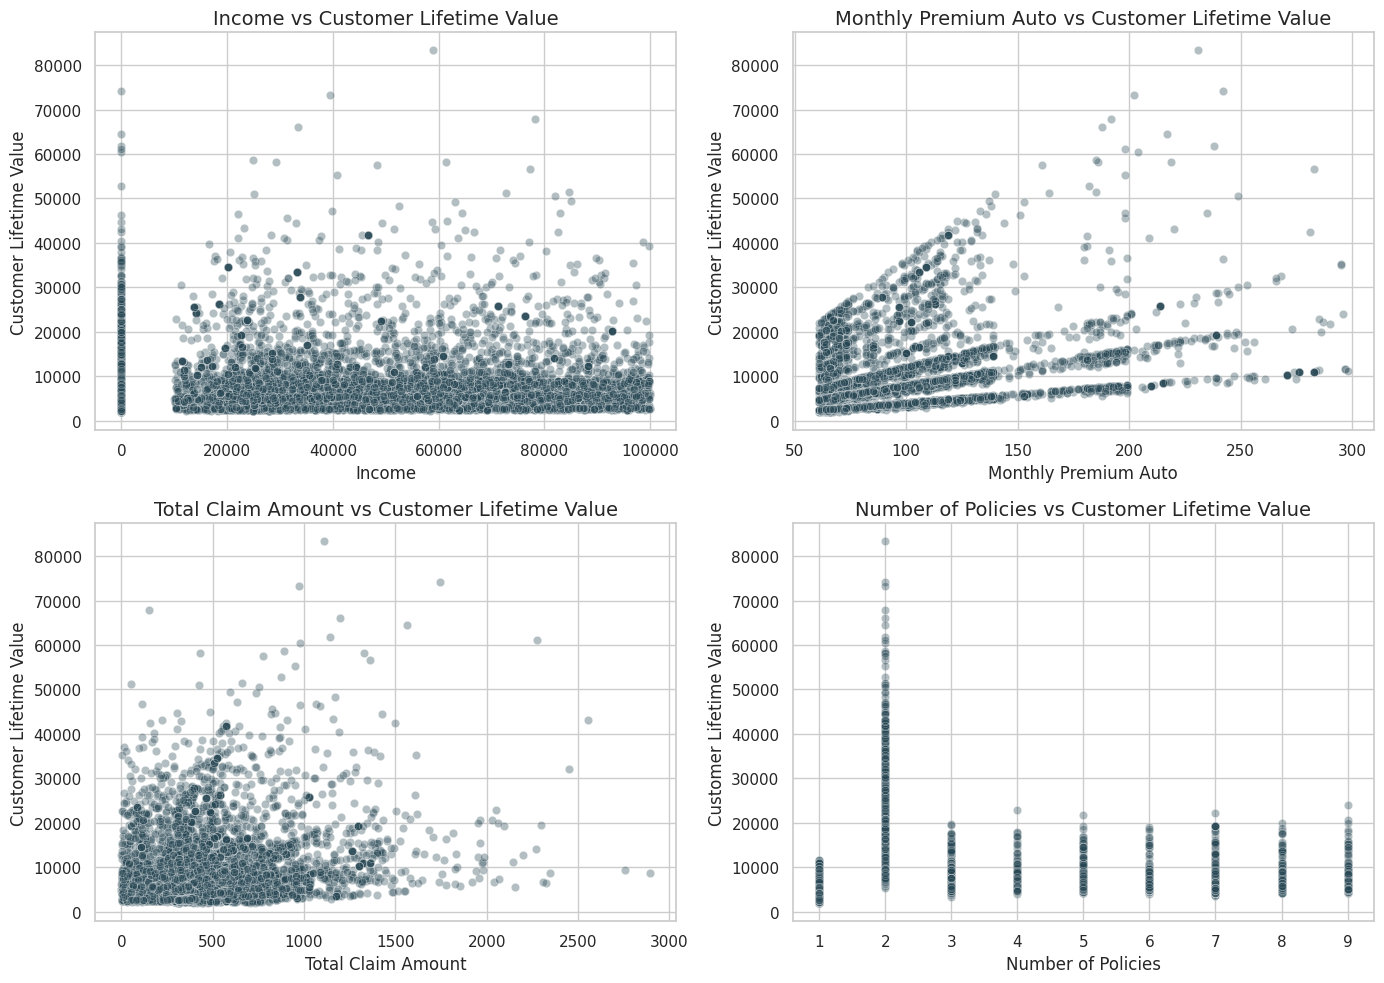

In [14]:
key_num_cols = ['Income', 'Monthly Premium Auto', 'Total Claim Amount', 'Number of Policies']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(key_num_cols):
    sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.35, ax=axes[i], color='#264653')
    axes[i].set_title(f'{col} vs {TARGET}')

plt.tight_layout()
plt.show()


### 8. Категориальные признаки: частоты и связь с целевой переменной

- для категориальных признаков полезно смотреть средний/медианный target по группам;
- так можно выделить категории, которые потенциально хорошо разделяют CLV.


In [15]:
cat_preview = ['Response', 'State', 'Coverage', 'Education', 'EmploymentStatus',
               'Gender', 'Location Code', 'Marital Status', 'Policy Type',
               'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size']

for col in cat_preview:
    print(f'\n=== {col} ===')
    display(df[col].value_counts(dropna=False).to_frame('count'))



=== Response ===


,count
Response,
No,7826
Yes,1308



=== State ===


,count
State,
California,3150
Oregon,2601
Arizona,1703
Nevada,882
Washington,798



=== Coverage ===


...

,count
Sales Channel,
Agent,3477
Branch,2567
Call Center,1765
Web,1325



=== Vehicle Class ===


,count
Vehicle Class,
Four-Door Car,4621
Two-Door Car,1886
SUV,1796
Sports Car,484
Luxury SUV,184
Luxury Car,163



=== Vehicle Size ===


,count
Vehicle Size,
Medsize,6424
Small,1764
Large,946



=== Response: агрегаты по target ===


,count,mean,median
Response,,,
No,7826,8030.022305,5814.145650
Yes,1308,7854.871361,5596.257433


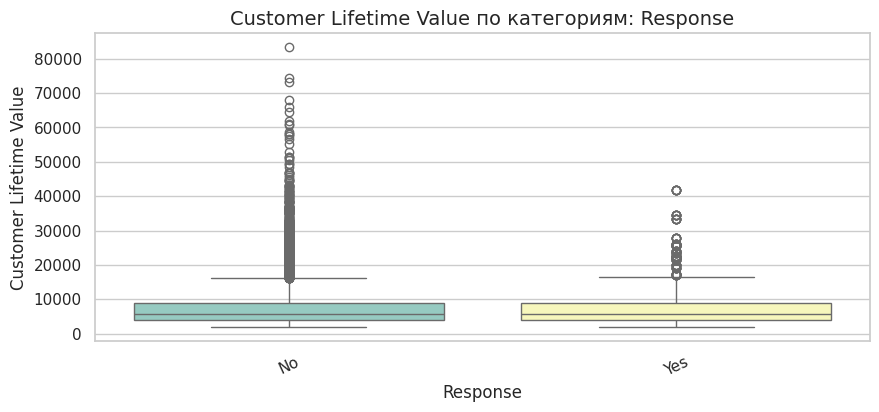


=== Coverage: агрегаты по target ===


,count,mean,median
Coverage,,,
Premium,824,10895.603083,8717.814857
Extended,2742,8789.677608,6627.161778
Basic,5568,7190.706422,5296.995144


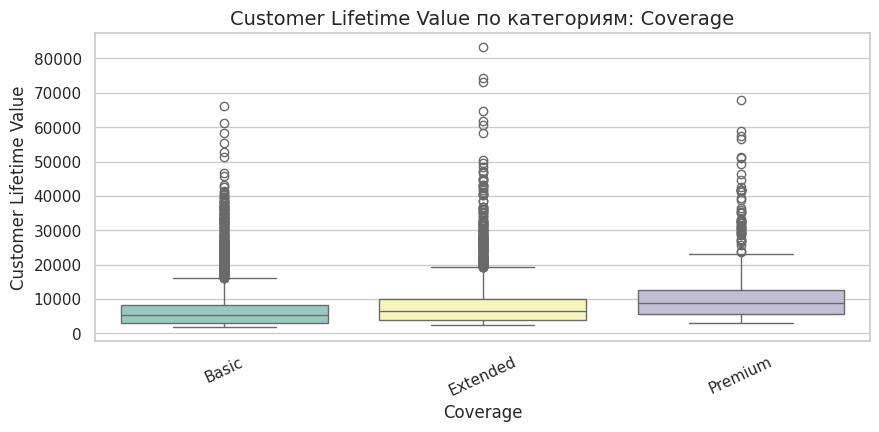


=== EmploymentStatus: агрегаты по target ===


,count,mean,median
EmploymentStatus,,,
Employed,5698,8219.117754,5863.592560
Disabled,405,7847.889354,5623.314472
Medical Leave,432,7641.822437,5258.924832
Unemployed,2317,7636.319761,5619.689084
Retired,282,7487.865141,5395.217776


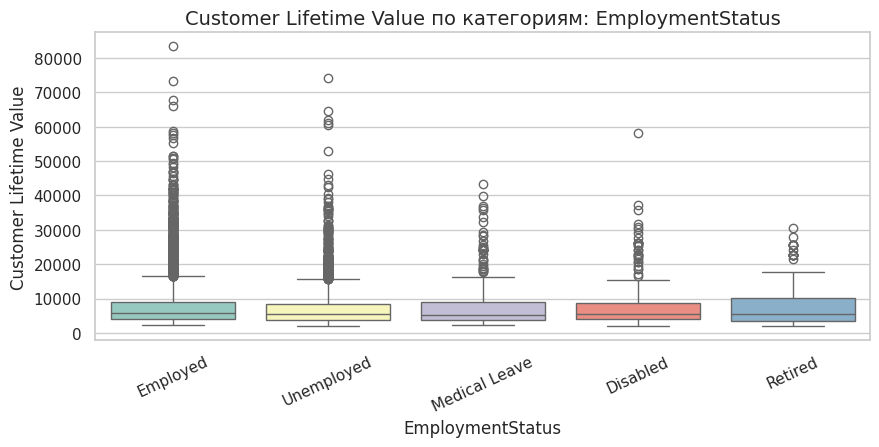


=== Policy Type: агрегаты по target ===


,count,mean,median
Policy Type,,,
Special Auto,378,8594.245038,6368.863221
Personal Auto,6788,8027.363535,5769.757360
Corporate Auto,1968,7814.409552,5735.775545


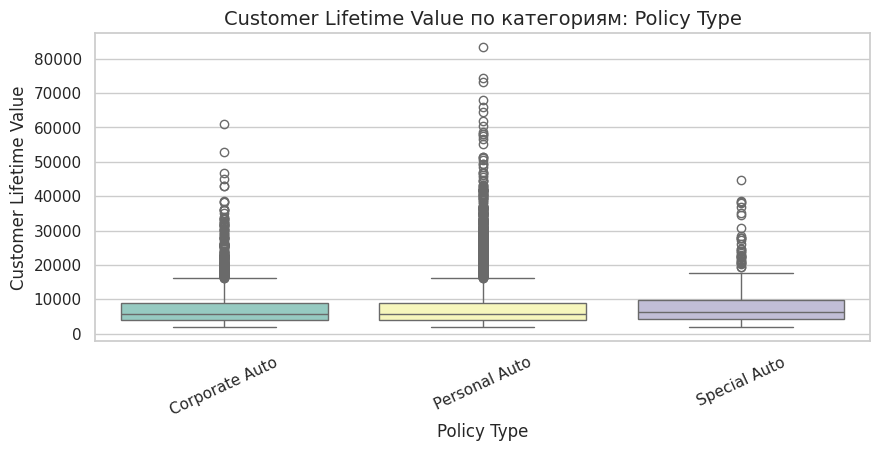


=== Vehicle Class: агрегаты по target ===


,count,mean,median
Vehicle Class,,,
Luxury SUV,184,17122.999134,14395.515695
Luxury Car,163,17053.348399,14510.443760
Sports Car,484,10750.989331,8554.788501
SUV,1796,10443.511816,8592.585972
Two-Door Car,1886,6671.030732,5266.700976
Four-Door Car,4621,6631.726607,5320.343098


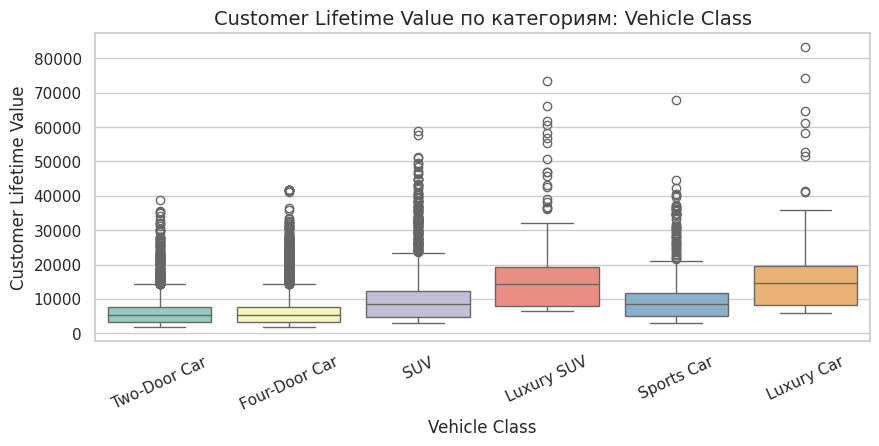


=== Sales Channel: агрегаты по target ===


,count,mean,median
Sales Channel,,,
Branch,2567,8119.711861,5802.835470
Call Center,1765,8100.085753,5780.182197
Agent,3477,7957.709353,5830.561364
Web,1325,7779.788057,5640.729767


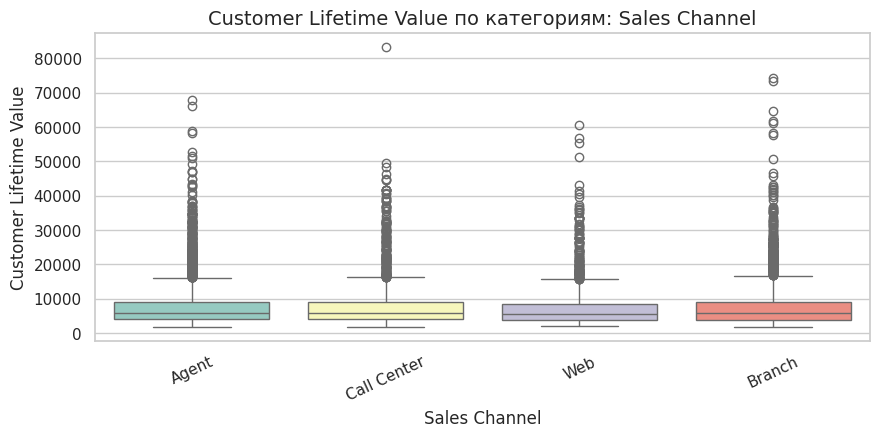

In [16]:
cat_for_target = ['Response', 'Coverage', 'EmploymentStatus', 'Policy Type', 'Vehicle Class', 'Sales Channel']

for col in cat_for_target:
    agg = (df.groupby(col)[TARGET]
           .agg(['count', 'mean', 'median'])
           .sort_values('mean', ascending=False))

    print(f'\n=== {col}: агрегаты по target ===')
    display(agg)

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=col, y=TARGET, palette='Set3')
    plt.title(f'{TARGET} по категориям: {col}')
    plt.xticks(rotation=25)
    plt.show()


### 9. Временной признак `Effective To Date`

- дата часто несёт сезонность/периодичность;
- в EDA проверяем базовое распределение записей по времени.


Количество записей по месяцам:
year_month
2011-01    4898
2011-02    4236
Name: count, dtype: int64


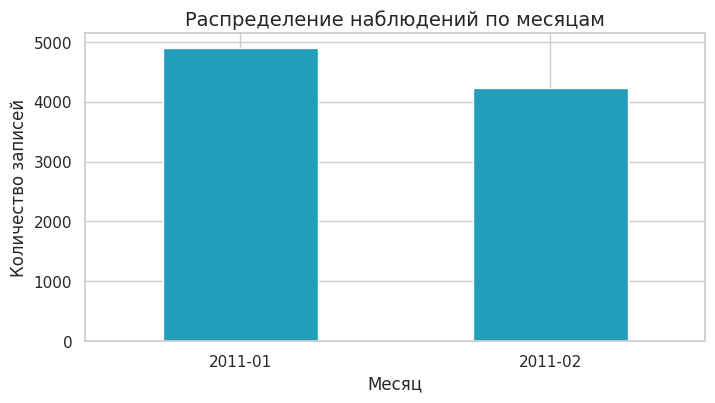

In [17]:
df['Effective To Date'] = pd.to_datetime(df['Effective To Date'], format='%m/%d/%y')
df['year_month'] = df['Effective To Date'].dt.to_period('M').astype(str)

month_counts = df['year_month'].value_counts().sort_index()
print('Количество записей по месяцам:')
print(month_counts)

plt.figure(figsize=(8, 4))
month_counts.plot(kind='bar', color='#219ebc')
plt.title('Распределение наблюдений по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество записей')
plt.xticks(rotation=0)
plt.show()


## 10. Итоговые выводы EDA для задачи CLV

1. Постановка задачи: **регрессия**, целевая переменная = `Customer Lifetime Value`.
2. Распределение CLV асимметрично вправо, присутствуют большие значения (выбросы); стоит рассмотреть `log1p`-преобразование на этапе моделирования.
3. В данных есть как числовые, так и категориальные признаки, что хорошо подходит для бустингов.
4. Категориальные признаки (включая `Response`) демонстрируют различия среднего/медианного CLV между группами.
5. Числовые признаки имеют разный масштаб и неодинаковую связь с target, что важно учесть при feature engineering.
6. Дата `Effective To Date` пригодна для извлечения дополнительных временных признаков (месяц, квартал и т.д.) в следующей части.



## Часть 2. Preprocessing & Feature Engineering

1. Соберём рабочий датафрейм для preprocessing (чтобы не ломать EDA-контекст).
2. Добавим новые признаки (feature engineering).
3. Уберём лишние/неподходящие колонки.
4. Разобьём данные на train/test.
5. Закодируем категориальные признаки через `LabelEncoder`.
6. Получим финальные матрицы `X_train`, `X_test`, `y_train`, `y_test`.


### 11. Базовая подготовка данных для preprocessing

- создаём отдельную копию `df_prep`, чтобы операции preprocessing не смешивались с шагами EDA;
- фиксируем целевую переменную `Customer Lifetime Value`.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

TARGET = 'Customer Lifetime Value'

df_prep = pd.read_csv(DATA_PATH)
print('Стартовая форма df_prep:', df_prep.shape)

df_prep.head(2)


Стартовая форма df_prep: (9134, 24)


,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize


### 12. Feature Engineering

Зачем добавляем новые признаки:
- бустинги хорошо работают с нелинейными зависимостями, поэтому полезно добавить осмысленные производные признаки;
- используем признаки, которые логически связаны с ценностью клиента (CLV).

Что добавляем:
- временные признаки из `Effective To Date`: `policy_month`, `policy_dayofweek`, `is_weekend_effective_date`;
- `premium_per_policy`: премия на один полис;
- `claim_to_premium_ratio`: отношение суммы claims к ежемесячной премии;
- `has_open_complaints`: индикатор наличия открытых жалоб.


In [19]:
# Преобразуем дату в datetime и извлекаем полезные компоненты

df_prep['Effective To Date'] = pd.to_datetime(df_prep['Effective To Date'], format='%m/%d/%y')
df_prep['policy_month'] = df_prep['Effective To Date'].dt.month
df_prep['policy_dayofweek'] = df_prep['Effective To Date'].dt.dayofweek
df_prep['is_weekend_effective_date'] = (df_prep['policy_dayofweek'] >= 5).astype(int)

# Защита от деления на ноль в ratio-признаках
safe_num_policies = df_prep['Number of Policies'].replace(0, 1)
safe_monthly_premium = df_prep['Monthly Premium Auto'].replace(0, 1)

df_prep['premium_per_policy'] = df_prep['Monthly Premium Auto'] / safe_num_policies
df_prep['claim_to_premium_ratio'] = df_prep['Total Claim Amount'] / safe_monthly_premium

df_prep['has_open_complaints'] = (df_prep['Number of Open Complaints'] > 0).astype(int)

print('Форма после feature engineering:', df_prep.shape)


Форма после feature engineering: (9134, 30)


### 13. Удаление лишних признаков

Что убираем и почему:
- `Customer`: это почти уникальный ID клиента, который обычно не несёт переносимой закономерности и может давать шум;
- `Effective To Date`: после извлечения компонент оставляем производные признаки, а исходную дату удаляем.


In [20]:
cols_to_drop = ['Customer', 'Effective To Date']
df_prep = df_prep.drop(columns=cols_to_drop)

print('Форма после удаления лишних колонок:', df_prep.shape)
print('Оставшиеся колонки:')
print(df_prep.columns.tolist())


Форма после удаления лишних колонок: (9134, 28)
Оставшиеся колонки:
['State', 'Customer Lifetime Value', 'Response', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Income', 'Location Code', 'Marital Status', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel', 'Total Claim Amount', 'Vehicle Class', 'Vehicle Size', 'policy_month', 'policy_dayofweek', 'is_weekend_effective_date', 'premium_per_policy', 'claim_to_premium_ratio', 'has_open_complaints']


### 14. Разделение на признаки и target + train/test split

Почему разделяем до кодирования:
- правильнее избегать утечки данных из test в train;
- кодировщики обучаем только на train-части.

Параметры split:
- `test_size=0.2`: 80/20;
- `random_state=42`: воспроизводимость эксперимента.


In [21]:
X = df_prep.drop(columns=[TARGET]).copy()
y = df_prep[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


X_train: (7307, 27)
X_test : (1827, 27)
y_train: (7307,)
y_test : (1827,)


### 15. Кодирование категориальных признаков через LabelEncoder

- по условию ДЗ используем `LabelEncoder`;
- fit делаем на train, чтобы не подглядывать в test;
- если в test встретится новая категория, помечаем её как `-1`.

Важно:
- для бустингов (деревьев) Label Encoding допустим;
- числовой порядок кодов не трактуется как реальный порядок категорий.


In [22]:
cat_cols_train = X_train.select_dtypes(include=['object']).columns.tolist()
print('Категориальные признаки для кодирования:')
print(cat_cols_train)

label_encoders = {}
unseen_stats = {}

for col in cat_cols_train:
    le = LabelEncoder()

    train_values = X_train[col].astype(str).fillna('MISSING')
    test_values = X_test[col].astype(str).fillna('MISSING')

    le.fit(train_values)

    X_train[col] = le.transform(train_values)

    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    X_test[col] = test_values.map(mapping).fillna(-1).astype(int)

    unseen_count = int((X_test[col] == -1).sum())
    unseen_stats[col] = unseen_count
    label_encoders[col] = le

print('Кодирование завершено.')
print('Количество unseen-категорий в test по колонкам:')
print({k: v for k, v in unseen_stats.items() if v > 0})


Категориальные признаки для кодирования:
['State', 'Response', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size']
Кодирование завершено.
Количество unseen-категорий в test по колонкам:
{}


### 16. Финальная проверка подготовленных данных

- убеждаемся, что все признаки числовые;
- проверяем отсутствие пропусков;
- фиксируем итоговый формат данных перед обучением моделей.


In [23]:
print('Типы данных в X_train после preprocessing:')
print(X_train.dtypes.value_counts())

print('Пропуски в X_train:', int(X_train.isna().sum().sum()))
print('Пропуски в X_test :', int(X_test.isna().sum().sum()))

print('Пример подготовленных признаков (train):')
display(X_train.head())


Типы данных в X_train после preprocessing:
int64      22
float64     3
int32       2
Name: count, dtype: int64
Пропуски в X_train: 0
Пропуски в X_test : 0
Пример подготовленных признаков (train):


,State,Response,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,Monthly Premium Auto,...,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size,policy_month,policy_dayofweek,is_weekend_effective_date,premium_per_policy,claim_to_premium_ratio,has_open_complaints
5123,4,0,0,0,1,1,51144,2,1,61,...,0,223.305224,5,1,1,0,0,6.777778,3.660741,1
7738,3,0,1,1,4,0,0,1,2,79,...,1,568.800000,0,1,2,4,0,79.000000,7.200000,0
214,0,0,0,1,1,1,81097,1,0,74,...,0,355.200000,0,2,2,0,0,74.000000,4.800000,0
8580,1,0,0,0,1,0,72264,2,1,64,...,3,272.649844,0,1,1,5,1,7.111111,4.260154,0
7857,4,0,0,0,1,0,54737,1,2,66,...,3,391.970334,0,1,1,1,0,66.000000,5.938944,0


### 17. Итог части 2

Что выполнено:
1. Категориальные переменные закодированы с помощью `LabelEncoder`.
2. Добавлены новые признаки (временные, признаки-отношения и бинарные индикаторы).
3. Удалены лишние признаки (`Customer`, исходная дата).
4. Данные разделены на train/test.

Результат:
- Получены готовые для обучения матрицы `X_train`, `X_test`, `y_train`, `y_test`.


## Часть 3. Who's the mightiest of them all?

Здесь сравниваем 4 реализации градиентного бустинга для задачи регрессии `Customer Lifetime Value`:
- `GradientBoostingRegressor` из `sklearn`;
- `XGBoost`;
- `CatBoost`;
- `LightGBM`.

План:
1. Обучить модели **из коробки** (базовые параметры).
2. Оценить качество на отложенной выборке.
3. Провести тюнинг основных гиперпараметров через кросс-валидацию.
4. Снова оценить качество на test и определить победителя.


### 18. Импорт моделей и метрик

- используем одинаковые метрики и одинаковый протокол оценки для всех моделей;
- это обеспечивает честное сравнение.


In [24]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, KFold

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# LightGBM ругается на пробелы в именах колонок, поэтому создаём безопасные копии признаков.
X_train_model = X_train.copy()
X_test_model = X_test.copy()
X_train_model.columns = [c.replace(' ', '_') for c in X_train_model.columns]
X_test_model.columns = [c.replace(' ', '_') for c in X_test_model.columns]


### 19. Общая функция оценки качества

Метрики:
- `MAE` — средняя абсолютная ошибка;
- `RMSE` — корень из средней квадратичной ошибки (сильнее штрафует крупные ошибки);
- `R2` — доля объяснённой дисперсии.

Для выбора победителя основной метрикой используем `RMSE` (меньше — лучше).


In [25]:
def evaluate_regression(model, X_train_data, y_train, X_test_data, y_test):
    model.fit(X_train_data, y_train)
    preds = model.predict(X_test_data)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'model_obj': model
    }


### 20. Модели из коробки

- сначала сравниваем baseline-варианты реализаций без тюнинга;
- это даёт честную отправную точку перед оптимизацией гиперпараметров.


In [26]:
base_models = {
    'sklearn_gbr': GradientBoostingRegressor(random_state=42),
    'xgboost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'catboost': CatBoostRegressor(verbose=0, random_state=42),
    'lightgbm': LGBMRegressor(random_state=42, verbose=-1)
}

base_results = []
base_fitted_models = {}

for name, model in base_models.items():
    metrics = evaluate_regression(model, X_train_model, y_train, X_test_model, y_test)
    base_fitted_models[name] = metrics.pop('model_obj')
    metrics['model'] = name
    base_results.append(metrics)

base_results_df = pd.DataFrame(base_results)[['model', 'MAE', 'RMSE', 'R2']].sort_values('RMSE')
base_results_df


,model,MAE,RMSE,R2
3,lightgbm,1584.406887,4003.446874,0.689003
2,catboost,1693.729016,4012.447126,0.687603
0,sklearn_gbr,1770.481064,4153.800513,0.665205
1,xgboost,1838.966792,4277.654194,0.644942


In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=base_results_df, x='model', y='RMSE', palette='Set2')
plt.title('RMSE моделей из коробки (меньше лучше)')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.show()


### Промежуточный вывод

- По таблице и графику видно, что с параметрами по умолчанию лидирует LightGBM.


### 21. Тюнинг гиперпараметров на кросс-валидации

- параметры по умолчанию редко оптимальны для конкретной задачи;
- кросс-валидация даёт более надёжную оценку качества кандидатов,
  чем единичный split.

Что тюним:
- число деревьев (`n_estimators`),
- глубину/сложность деревьев,
- `subsample`,
- аналог `max_features` (`max_features`, `colsample_bytree`, `feature_fraction`).


In [ ]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)
scoring = 'neg_root_mean_squared_error'


In [ ]:
search_spaces = {
    'sklearn_gbr': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.03, 0.05, 0.1],
            'max_depth': [2, 3, 4],
            'subsample': [0.7, 0.85, 1.0],
            'max_features': [None, 'sqrt', 'log2']
        }
    },
    'xgboost': {
        'model': XGBRegressor(objective='reg:squarederror', random_state=42),
        'params': {
            'n_estimators': [150, 300, 500, 700],
            'learning_rate': [0.03, 0.05, 0.1],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.85, 1.0],
            'colsample_bytree': [0.7, 0.85, 1.0]
        }
    },
    'catboost': {
        'model': CatBoostRegressor(verbose=0, random_state=42),
        'params': {
            'n_estimators': [200, 400, 700],
            'learning_rate': [0.03, 0.05, 0.1],
            'depth': [4, 6, 8],
            'subsample': [0.7, 0.85, 1.0],
            'l2_leaf_reg': [1, 3, 5, 7, 9]
        }
    },
    'lightgbm': {
        'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [150, 300, 500, 700],
            'learning_rate': [0.03, 0.05, 0.1],
            'max_depth': [-1, 4, 6, 8],
            'num_leaves': [15, 31, 63],
            'subsample': [0.7, 0.85, 1.0],
            'colsample_bytree': [0.7, 0.85, 1.0]
        }
    }
}


In [31]:
def run_random_search(model, param_distributions, X_train, y_train, cv, scoring, n_iter=12):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)
    return search


In [32]:
tuned_results = []
tuned_models = {}
search_objects = {}

for name, cfg in search_spaces.items():
    print(f'Tuning: {name}')
    search = run_random_search(
        model=cfg['model'],
        param_distributions=cfg['params'],
        X_train=X_train_model,
        y_train=y_train,
        cv=cv,
        scoring=scoring,
        n_iter=12
    )

    best_model = search.best_estimator_
    search_objects[name] = search
    tuned_models[name] = best_model

    preds = best_model.predict(X_test_model)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    tuned_results.append({
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'cv_best_rmse': -search.best_score_,
        'best_params': search.best_params_
    })


Tuning: sklearn_gbr
Tuning: xgboost
Tuning: catboost
Tuning: lightgbm


In [33]:
tuned_results_df = pd.DataFrame(tuned_results)[['model', 'MAE', 'RMSE', 'R2', 'cv_best_rmse', 'best_params']].sort_values('RMSE')
tuned_results_df


,model,MAE,RMSE,R2,cv_best_rmse,best_params
2,catboost,1619.454633,3962.262270,0.695369,3694.170048,"{'subsample': 0.85, 'n_estimators': 400, 'lear..."
3,lightgbm,1587.050638,4024.889897,0.685663,3745.682070,"{'subsample': 0.85, 'num_leaves': 31, 'n_estim..."
1,xgboost,1584.941683,4067.511815,0.678970,3738.391967,"{'subsample': 0.7, 'n_estimators': 150, 'max_d..."
0,sklearn_gbr,1714.084307,4112.706193,0.671796,3787.400214,"{'subsample': 0.7, 'n_estimators': 100, 'max_f..."


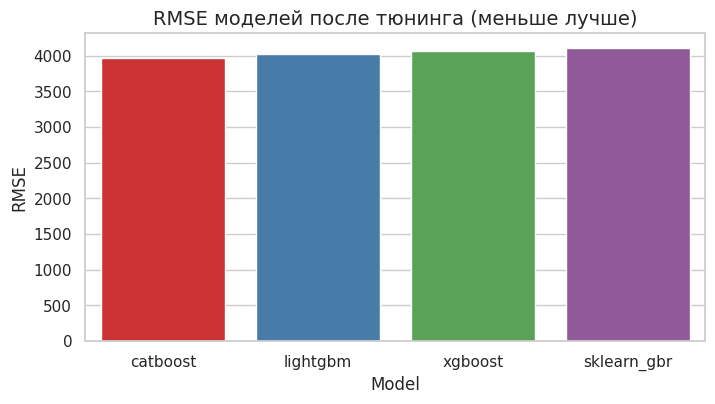

In [34]:
plt.figure(figsize=(8, 4))
sns.barplot(data=tuned_results_df, x='model', y='RMSE', palette='Set1')
plt.title('RMSE моделей после тюнинга (меньше лучше)')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.show()


### 22. Сравнение до/после тюнинга

- проверяем, дал ли тюнинг реальное улучшение;
- фиксируем финального победителя на test-выборке.


In [35]:
compare_df = base_results_df[['model', 'RMSE', 'MAE', 'R2']].merge(
    tuned_results_df[['model', 'RMSE', 'MAE', 'R2']],
    on='model',
    suffixes=('_base', '_tuned')
)

compare_df['RMSE_improvement'] = compare_df['RMSE_base'] - compare_df['RMSE_tuned']
compare_df = compare_df.sort_values('RMSE_tuned')
compare_df


,model,RMSE_base,MAE_base,R2_base,RMSE_tuned,MAE_tuned,R2_tuned,RMSE_improvement
1,catboost,4012.447126,1693.729016,0.687603,3962.262270,1619.454633,0.695369,50.184855
0,lightgbm,4003.446874,1584.406887,0.689003,4024.889897,1587.050638,0.685663,-21.443023
3,xgboost,4277.654194,1838.966792,0.644942,4067.511815,1584.941683,0.678970,210.142379
2,sklearn_gbr,4153.800513,1770.481064,0.665205,4112.706193,1714.084307,0.671796,41.094321


In [ ]:
best_base = base_results_df.iloc[0]
best_tuned = tuned_results_df.iloc[0]

print('Лучший из коробки:')
print(f"model: {best_base['model']}")
print(f"RMSE : {best_base['RMSE']:.6f}")
print(f"MAE  : {best_base['MAE']:.6f}")
print(f"R2   : {best_base['R2']:.6f}")

print('\nЛучший после тюнинга:')
print(f"model       : {best_tuned['model']}")
print(f"RMSE        : {best_tuned['RMSE']:.6f}")
print(f"MAE         : {best_tuned['MAE']:.6f}")
print(f"R2          : {best_tuned['R2']:.6f}")
print(f"cv_best_rmse: {best_tuned['cv_best_rmse']:.6f}")

print('\nЕго лучшие параметры:')
for k, v in best_tuned['best_params'].items():
    print(f"- {k}: {v}")


## 23. Вывод по части 3

### Итоги сравнения моделей

1. **Лучший из коробки**: `LightGBM`  
   - RMSE: `4003.446874`  
   - MAE: `1584.406887`  
   - R2: `0.689003`

2. **Лучший после тюнинга на CV**: `CatBoost`  
   - RMSE: `3962.262270`  
   - MAE: `1619.454633`  
   - R2: `0.695369`  
   - CV best RMSE: `3694.170048`  
   - Лучшие параметры: `{'subsample': 0.85, 'n_estimators': 400, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'depth': 8}`

3. **Изменение после тюнинга**
- `CatBoost` улучшил RMSE относительно своего baseline (`4012.447126 -> 3962.262270`) и стал лидером.
- `LightGBM` был лучшим без тюнинга, но после тюнинга уступил `CatBoost` по RMSE.
- `XGBoost` заметно улучшился относительно baseline, но не стал лучшим по RMSE.
- `sklearn GradientBoosting` остался самым слабым по RMSE среди 4 моделей.

### Интерпретация

Для задачи прогнозирования `Customer Lifetime Value` (регрессия) итоговым победителем в этом эксперименте является **CatBoost после тюнинга** по основной метрике `RMSE` (минимальное значение на отложенной выборке). Это означает, что в текущем пайплайне именно CatBoost лучше всего снижает величину крупных ошибок прогноза CLV.

Обоснование корректности сравнения:
- все модели обучались на одном и том же train/test split;
- тюнинг делался на train через кросс-валидацию;
- финальное сравнение проводилось на test, который не использовался для fit моделей.

